In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv("sb3_train_results.csv")
df

,corpus_size,run,episode,avg_reward
0,5,1,1,-0.002623
1,5,1,2,-0.002811
2,5,1,3,-0.001865
3,5,1,4,-0.004750
4,5,1,5,-0.001201
...,...,...,...,...
123,5,1,124,-0.001641
124,5,1,125,-0.003345
125,5,1,126,-0.004081
126,5,1,127,-0.001662


In [4]:
episode_rewards = df.groupby(["run", "episode", "corpus_size"])["avg_reward"].mean().reset_index()
run_stats = episode_rewards.groupby(["episode", "corpus_size"])["avg_reward"].agg(["mean", "std"]).reset_index()
run_stats

,episode,corpus_size,mean,std
0,1,5,-0.003250,0.001394
1,1,10,-0.000433,0.000879
2,1,20,-0.008227,0.003472
3,1,40,-0.011058,0.005796
4,2,5,-0.002444,0.000999
...,...,...,...,...
507,127,40,-0.012417,0.006507
508,128,5,-0.002464,0.001079
509,128,10,-0.001027,0.001048
510,128,20,-0.006174,0.005708


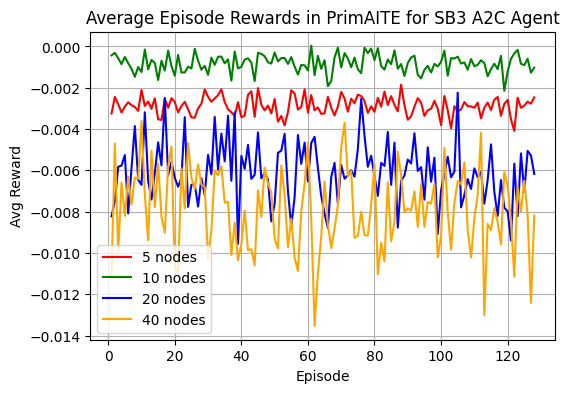

In [6]:
import seaborn as sns

colours = ["red", "green", "blue", "orange"]
plt.figure(figsize=(6, 4))
for index, corpus_size in enumerate(run_stats["corpus_size"].unique()):
    subset = run_stats[run_stats["corpus_size"] == corpus_size]
    plt.plot(subset["episode"], subset["mean"], color=colours[index], label=str(corpus_size) + " nodes")
    # plt.errorbar(
    # subset["episode"], subset["mean"], yerr=subset["std"], color=colours[index], capsize=2, elinewidth=1.0
    # )
plt.xlabel("Episode")
plt.ylabel("Avg Reward")
plt.title("Average Episode Rewards in PrimAITE for SB3 A2C Agent")
plt.grid(True)
plt.legend()